# Análise Exploratória: Baixo Orçamento, Alta Rentabilidade

**Responsável**: Gabriel Costa Morais

**Pergunta Central**: Filmes baratos podem ser mais lucrativos que filmes caros?

___

## 🎯 Motivação e hipóteses

Entre produtoras, cineastas e entusiastas do cinema, há uma ideia de que grandes bilheterias exigem investimentos astronômicos em produções blockbuster. Diante desse pensamento, surge o interesse de, por meio de uma análise de dados, averiguar se realmente esse raciocício condiz com a realidade do cenário da sétima arte.

Para esta análise, os filmes foram categorizados de acordo com os seus orçamentos de produção, divididos em: 
- **Baixo (até US$ 6 milhões)**

- **Médio (até US$ 17 milhões)**

- **Alto (até US$ 39 milhões)**

Estes limites foram estabelicidos através do cálculo dos quartis dos orçamentos dos filmes, a fim de dividir quais filmes seriam considerados "baratos", na "média" e "caros".

Mediante isso foram levantadas duas hipóteses:

1. Qual a porcentagem do retorno sobre o investimento (ROI) mediano de cada categoria?
2. Qual o lucro médio que cada uma dessas categorias obteve? 

___

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("df_omdb.csv")

df.head()

,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,original_language,is_franchise,budget,revenue,metascore_critica
0,tt0004972,movie,The Birth of a Nation,1915,195,"Drama,War",6.1,28372,en,True,100000.0,11000000.0,-1
1,tt0006864,movie,Intolerance,1916,210,"Drama,History",7.6,18046,en,False,385907.0,1750000.0,99
2,tt0009968,movie,Broken Blossoms,1919,90,"Drama,Romance",7.2,11791,en,False,0.0,2400000.0,-1
3,tt0010323,movie,The Cabinet of Dr. Caligari,1920,67,"Horror,Mystery,Thriller",8.0,76445,de,False,18000.0,8811.0,-1
4,tt0012349,movie,The Kid,1921,68,"Comedy,Drama,Family",8.2,146100,en,False,250000.0,5450000.0,-1


In [3]:
df.shape

(12455, 13)

In [5]:
df.describe()


,startYear,runtimeMinutes,averageRating,numVotes,budget,revenue,metascore_critica
count,12455.000000,12455.000000,12455.000000,1.245500e+04,1.245200e+04,1.245200e+04,12455.000000
mean,2003.341790,110.401766,6.583677,9.064456e+04,2.085616e+07,5.868885e+07,44.961863
std,19.019759,22.928544,1.011805,1.788383e+05,3.825316e+07,1.500852e+08,29.519971
min,1915.000000,45.000000,1.000000,1.000100e+04,0.000000e+00,0.000000e+00,-1.000000
25%,1995.000000,95.000000,6.000000,1.619850e+04,0.000000e+00,2.948000e+03,24.000000
50%,2008.000000,106.000000,6.700000,3.166600e+04,6.000000e+06,8.853539e+06,51.000000
75%,2017.000000,120.000000,7.300000,8.410150e+04,2.500000e+07,4.744955e+07,68.000000
max,2026.000000,566.000000,9.300000,3.203207e+06,6.588000e+08,2.923706e+09,100.000000


In [6]:
df[["budget", "revenue"]].describe()

print("Total de filmes:", len(df))

print(
    "Com orçamento:",
    (df["budget"] > 0).sum()
)

print(
    "Com receita:",
    (df["revenue"] > 0).sum()
)

print(
    "Com orçamento E receita:",
    (
        (df["budget"] > 0) &
        (df["revenue"] > 0)
    ).sum()
)

Total de filmes: 12455
Com orçamento: 8549
Com receita: 9368
Com orçamento E receita: 7835


In [7]:
df_financeiro = df[
    (df["budget"] > 0) &
    (df["revenue"] > 0)
].copy()

print("Filmes na análise:", len(df_financeiro))

Filmes na análise: 7835


In [ ]:
# isso no caso não representa o lucro real do estúdio.
# está sendo ignorando custos como marketing, distribuição e a divisão da bilheteria entre estúdio e cinemas.

df_financeiro["lucro_estimado"] = (
    df_financeiro["revenue"] -
    df_financeiro["budget"]
)

In [9]:
# Cálculo do ROI (Retorno sobre o Investimento)

df_financeiro["roi"] = (
    (df_financeiro["revenue"] -
     df_financeiro["budget"])
    / df_financeiro["budget"]
) * 100

#ROI positivo: receita maior que o orçamento.
#ROI igual a 0%: receita igual ao orçamento.
#ROI negativo: receita menor que o orçamento.

In [10]:
df_financeiro[
    [
        "primaryTitle",
        "startYear",
        "budget",
        "revenue",
        "lucro_estimado",
        "roi"
    ]
].head()

,primaryTitle,startYear,budget,revenue,lucro_estimado,roi
0,The Birth of a Nation,1915,100000.0,11000000.0,10900000.0,10900.000000
1,Intolerance,1916,385907.0,1750000.0,1364093.0,353.477133
3,The Cabinet of Dr. Caligari,1920,18000.0,8811.0,-9189.0,-51.050000
4,The Kid,1921,250000.0,5450000.0,5200000.0,2080.000000
10,Safety Last!,1923,121000.0,1500000.0,1379000.0,1139.669421


In [11]:
#Verificando os maiores ROI

df_financeiro.sort_values(
    "roi",
    ascending=False
)[
    [
        "primaryTitle",
        "startYear",
        "budget",
        "revenue",
        "lucro_estimado",
        "roi"
    ]
].head(20)

,primaryTitle,startYear,budget,revenue,lucro_estimado,roi
9698,The Beatles: Eight Days a Week - The Touring Y...,2016,5.0,12283800.0,12283795.0,2.456759e+08
5231,The Notorious Bettie Page,2005,90.0,1410778.0,1410688.0,1.567431e+06
7060,Paranormal Activity,2007,15000.0,193355800.0,193340800.0,1.288939e+06
3899,The Blair Witch Project,1999,60000.0,248639099.0,248579099.0,4.142985e+05
1008,Fist of Fury,1972,100000.0,100000000.0,99900000.0,9.990000e+04
10676,Obsession,2025,750000.0,404401180.0,403651180.0,5.382016e+04
12022,One Cut of the Dead,2017,52406.0,27590180.0,27537774.0,5.254699e+04
1015,Pink Flamingos,1972,12000.0,6000000.0,5988000.0,4.990000e+04
11542,Secret Superstar,2017,286284.0,137416709.0,137130425.0,4.790014e+04
4998,Open Water,2003,120000.0,54683487.0,54563487.0,4.546957e+04


In [12]:
df_financeiro.sort_values(
    "budget",
    ascending=True
)[
    [
        "primaryTitle",
        "startYear",
        "budget",
        "revenue"
    ]
].head(30)

,primaryTitle,startYear,budget,revenue
8055,The Quiet Girl,2022,1.0,6.0
6030,Red Dog,2011,5.0,13.0
9698,The Beatles: Eight Days a Week - The Touring Y...,2016,5.0,12283800.0
2340,My Blue Heaven,1990,6.0,23.0
5231,The Notorious Bettie Page,2005,90.0,1410778.0
7573,Rampage,2009,120.0,428.0
5913,10 Items or Less,2006,400.0,1.0
12231,Freaks,2018,2000.0,368410.0
3736,Following,1998,6000.0,126052.0
5143,Primer,2004,7000.0,545436.0


In [13]:
df_financeiro.sort_values(
    "roi",
    ascending=False
)[
    [
        "primaryTitle",
        "startYear",
        "budget",
        "revenue",
        "roi"
    ]
].head(30)

,primaryTitle,startYear,budget,revenue,roi
9698,The Beatles: Eight Days a Week - The Touring Y...,2016,5.0,12283800.0,2.456759e+08
5231,The Notorious Bettie Page,2005,90.0,1410778.0,1.567431e+06
7060,Paranormal Activity,2007,15000.0,193355800.0,1.288939e+06
3899,The Blair Witch Project,1999,60000.0,248639099.0,4.142985e+05
1008,Fist of Fury,1972,100000.0,100000000.0,9.990000e+04
10676,Obsession,2025,750000.0,404401180.0,5.382016e+04
12022,One Cut of the Dead,2017,52406.0,27590180.0,5.254699e+04
1015,Pink Flamingos,1972,12000.0,6000000.0,4.990000e+04
11542,Secret Superstar,2017,286284.0,137416709.0,4.790014e+04
4998,Open Water,2003,120000.0,54683487.0,4.546957e+04


In [14]:
df_financeiro[df_financeiro["budget"] < 1000][
    [
        "primaryTitle",
        "startYear",
        "budget",
        "revenue"
    ]
]

,primaryTitle,startYear,budget,revenue
2340,My Blue Heaven,1990,6.0,23.0
5231,The Notorious Bettie Page,2005,90.0,1410778.0
5913,10 Items or Less,2006,400.0,1.0
6030,Red Dog,2011,5.0,13.0
7573,Rampage,2009,120.0,428.0
8055,The Quiet Girl,2022,1.0,6.0
9698,The Beatles: Eight Days a Week - The Touring Y...,2016,5.0,12283800.0


In [15]:
df_financeiro["budget"].describe()

count    7.835000e+03
mean     3.191500e+07
std      4.382557e+07
min      1.000000e+00
25%      6.000000e+06
50%      1.700000e+07
75%      3.900000e+07
max      6.588000e+08
Name: budget, dtype: float64

In [16]:
df_financeiro["revenue"].describe()

count    7.835000e+03
mean     9.141952e+07
std      1.811656e+08
min      1.000000e+00
25%      8.437245e+06
50%      2.936499e+07
75%      9.330149e+07
max      2.923706e+09
Name: revenue, dtype: float64

In [17]:
df_financeiro[df_financeiro["budget"] < 1000000][
    [
        "primaryTitle",
        "startYear",
        "budget",
        "revenue"
    ]
].sort_values("budget").head(50)

,primaryTitle,startYear,budget,revenue
8055,The Quiet Girl,2022,1.0,6.0
6030,Red Dog,2011,5.0,13.0
9698,The Beatles: Eight Days a Week - The Touring Y...,2016,5.0,12283800.0
2340,My Blue Heaven,1990,6.0,23.0
5231,The Notorious Bettie Page,2005,90.0,1410778.0
7573,Rampage,2009,120.0,428.0
5913,10 Items or Less,2006,400.0,1.0
12231,Freaks,2018,2000.0,368410.0
3736,Following,1998,6000.0,126052.0
5143,Primer,2004,7000.0,545436.0


In [18]:
df_financeiro["budget"].value_counts(bins=[0, 1000, 10000, 100000, 1000000, 5000000, 10000000, 50000000, float("inf")]).sort_index()

(-0.001, 1000.0]               7
(1000.0, 10000.0]              8
(10000.0, 100000.0]           62
(100000.0, 1000000.0]        446
(1000000.0, 5000000.0]      1319
(5000000.0, 10000000.0]     1111
(10000000.0, 50000000.0]    3487
(50000000.0, inf]           1395
Name: count, dtype: int64

In [19]:
df_financeiro[df_financeiro["budget"] < 1000][
    [
        "primaryTitle",
        "startYear",
        "budget",
        "revenue"
    ]
].sort_values("budget")

,primaryTitle,startYear,budget,revenue
8055,The Quiet Girl,2022,1.0,6.0
6030,Red Dog,2011,5.0,13.0
9698,The Beatles: Eight Days a Week - The Touring Y...,2016,5.0,12283800.0
2340,My Blue Heaven,1990,6.0,23.0
5231,The Notorious Bettie Page,2005,90.0,1410778.0
7573,Rampage,2009,120.0,428.0
5913,10 Items or Less,2006,400.0,1.0


In [ ]:
#Antes tinhamos 7835 filmes

df_financeiro = df_financeiro[
    df_financeiro["budget"] >= 1000
].copy()

print(f"Filmes após a limpeza: {len(df_financeiro)}")

Filmes após a limpeza: 7828


In [22]:
#Lucro estimado

df_financeiro["lucro"] = (
    df_financeiro["revenue"] -
    df_financeiro["budget"]
)

In [ ]:
#ROI (Retorno sobre o investimento (%))

df_financeiro["roi"] = (
    df_financeiro["lucro"] /
    df_financeiro["budget"]
) * 100

In [23]:
#Utilizando os quartis que encontramos: Q1: US$ 6 milhões  // Q2 (mediana): US$ 17 milhões // Q3: US$ 39 milhões

def categoria_orcamento(valor):

    if valor < 6_000_000:
        return "Baixo"

    elif valor < 39_000_000:
        return "Médio"

    else:
        return "Alto"

df_financeiro["categoria"] = (
    df_financeiro["budget"]
    .apply(categoria_orcamento)
)

In [24]:
df_financeiro["categoria"].value_counts()

categoria
Médio    3946
Alto     1966
Baixo    1916
Name: count, dtype: int64

In [25]:
analise = (
    df_financeiro
    .groupby("categoria")
    .agg(
        quantidade=("primaryTitle", "count"),
        orcamento_medio=("budget", "mean"),
        receita_media=("revenue", "mean"),
        lucro_medio=("lucro", "mean"),
        roi_medio=("roi", "mean"),
        roi_mediano=("roi", "median")
    )
)

analise

,quantidade,orcamento_medio,receita_media,lucro_medio,roi_medio,roi_mediano
categoria,,,,,,
Alto,1966,8.826686e+07,2.450000e+08,1.567331e+08,160.220405,107.888663
Baixo,1916,2.552951e+06,1.682963e+07,1.427668e+07,2019.400902,208.577354
Médio,3946,1.815255e+07,5.127793e+07,3.312539e+07,210.763200,73.315642


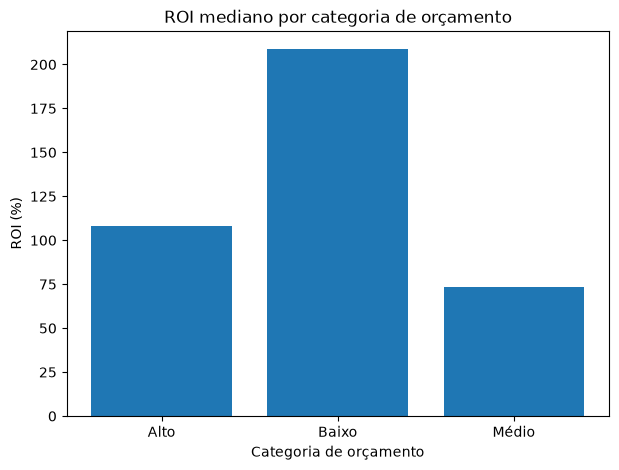

In [26]:
import matplotlib.pyplot as plt

roi_mediano = (
    df_financeiro
    .groupby("categoria")["roi"]
    .median()
)

plt.figure(figsize=(7,5))

plt.bar(
    roi_mediano.index,
    roi_mediano.values
)

plt.title("ROI mediano por categoria de orçamento")

plt.xlabel("Categoria de orçamento")

plt.ylabel("ROI (%)")

plt.show()

# 💭 Dedução da primeira hipótese:

A mediana nos mostra uma informação muito interessante em relação as categorias:


- **Categoria**: Baixo --> **ROI mediano**: 209%

- **Categoria**: Alto --> **ROI mediano**: 108%

- **Categoria**: Médio --> **ROI mediano**: 73%

Isso nos indica que o filme barato "típico" apresenta um retorno percentual **maior** sobre o investimento do que o filme médio ou caro.


___

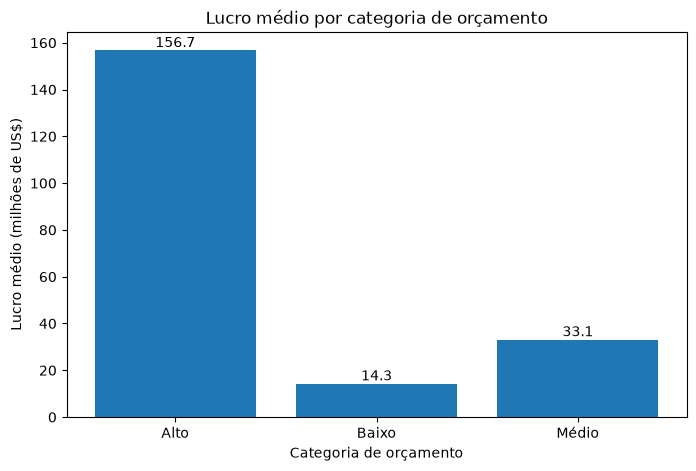

In [29]:
import matplotlib.pyplot as plt

lucro_medio = analise["lucro_medio"] / 1_000_000  # Converter para milhões

plt.figure(figsize=(8,5))

plt.bar(
    lucro_medio.index,
    lucro_medio.values
)

plt.title("Lucro médio por categoria de orçamento")

plt.xlabel("Categoria de orçamento")

plt.ylabel("Lucro médio (milhões de US$)")


for i, valor in enumerate(lucro_medio.values):
    plt.text(i, valor, f"{valor:.1f}", ha="center", va="bottom")

plt.show()

# 💭 Dedução da segunda hipótese:

Analisando o lucro médio:

- **Categoria**: Alto	**Lucro médio**: US$ 156,7 milhões

- **Categoria**: Médio	**Lucro médio**: US$ 33,1 milhões

- **Categoria**: Baixo	**Lucro médio**: US$ 14,3 milhões

Ou seja, os filmes caros geram, em média, **mais de 10 vezes** o lucro absoluto dos filmes baratos.